---
numbering:
  enumerator: "16.%s"
  headings: true
  equation:
    template: "%s"
---
(chap_undertainty)=
# Uncertainty quantification and conformal prediction

Standard machine learning models produce point estimates. They offer no indication of reliability. An investor who knows a forecast is imprecise can reduce position sizes and avoid costly errors. Uncertainty quantification (UQ) addresses this gap. UQ attaches a measure of confidence to every prediction. It therefore transforms a raw signal into actionable information.

This chapter covers three traditions in UQ as applied to asset pricing. The first is conformal prediction, which delivers finite sample, distribution free coverage guarantees. The second is ambiguity aversion, which models investor behavior under Knightian uncertainty about the return generating process. The third is machine forecast disagreement, which treats dispersion across ML models as a proxy for hard to price risk. Together, these traditions offer a rich toolkit for practitioners who take model uncertainty seriously.

(sec_uncertainty_types)=
## Sources of prediction uncertainty

Prediction uncertainty has two conceptually distinct sources. **Aleatoric** uncertainty is irreducible. It arises from idiosyncratic shocks that no model can eliminate regardless of sample size. In factor investing, idiosyncratic return variance is a canonical example. No amount of additional data removes it.

**Epistemic** uncertainty is reducible in principle. It stems from finite data and from limitations of the chosen model class. A model trained on few observations will disagree with a model trained on many. That disagreement shrinks as data accumulate. The two components call for different responses: aleatoric uncertainty should inform position sizing, while epistemic uncertainty motivates model averaging or Bayesian approaches.

Decomposing these components formally is not straightforward. @ahdritz2024calibration introduce higher order calibration to achieve this decomposition with formal guarantees. Their framework requires no distributional assumptions on the data generating process. It provides a provably valid separation between aleatoric and epistemic contributions to total prediction error.

(sec_conformal)=
## Conformal prediction

Conformal prediction is a framework for constructing prediction intervals that carry a finite sample, distribution free coverage guarantee. Under exchangeability of the data, the coverage holds exactly regardless of the underlying distribution and regardless of the model used to generate predictions. The foundational theory is laid out in @vovk2005algorithmic. A concise and accessible introduction is provided by @angelopoulos2023gentle.

The key appeal in financial applications is the absence of parametric assumptions. Return distributions have heavy tails and change over time. Classical interval methods that assume normality are unreliable. Conformal methods sidestep this entirely. @liao2025uncertainty apply related ideas to asset pricing and show that neural network forecasts share an asymptotic distribution with nonparametric estimators, enabling closed form standard errors and bootstrap confidence intervals. They find that accounting for forecast uncertainty improves out of sample portfolio performance.

### The split conformal algorithm

The split conformal algorithm proceeds in three steps. First, the data are partitioned into a training set, a calibration set, and a test set. Second, a model $\hat{f}$ is fitted on the training set and used to predict on the calibration set. Third, nonconformity scores are computed, a quantile is derived from these scores, and intervals are formed for the test observations.

The coverage guarantee states that for a chosen miscoverage level $\alpha \in (0,1)$,

```{math}
:label: eq_conformal_coverage
P(y_{n+1} \in \hat{C}(x_{n+1})) \geq 1 - \alpha.
```

The nonconformity score for calibration observation $i$ is the absolute residual of the model:

```{math}
:label: eq_nonconformity
s_i = |y_i - \hat{f}(x_i)|.
```

The prediction interval for a new observation $x_{n+1}$ is then

```{math}
:label: eq_conformal_interval
\hat{C}(x_{n+1}) = [\hat{f}(x_{n+1}) - \hat{q},\; \hat{f}(x_{n+1}) + \hat{q}],
```

where $\hat{q}$ is the $\lceil(n+1)(1-\alpha)\rceil/n$ quantile of the calibration scores. This inflated quantile accounts for the finite size of the calibration set and is what delivers the guarantee in {eq}`eq_conformal_coverage`. The interval is symmetric around the point prediction. It grows wider as $\alpha$ decreases (tighter coverage) and narrows as the calibration set grows.

The code below illustrates split conformal prediction on the book's US stock data. We use the seven standard characteristics from the dataset as predictors of next month returns. A ridge regression is trained on observations before 2013. The calibration set covers 2013 to 2016 and is used to derive the conformal quantile. The test set runs from 2017 onward.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

pd.set_option('display.max_columns', 10)
plt.style.use('seaborn-v0_8-whitegrid')

from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

cols_needed = ['date', 'fsym_id'] + features_short + ['R1M']
data_clean  = data_ml[cols_needed].dropna().copy()
data_clean['date'] = pd.to_datetime(data_clean['date'])
data_clean  = data_clean.sort_values('date').reset_index(drop=True)

print(f"Dataset: {len(data_clean):,} stock-month observations")
print(f"Date range: {data_clean['date'].min().date()} to {data_clean['date'].max().date()}")
print(f"Features: {features_short}")

Dataset: 365,050 stock-month observations
Date range: 2002-01-31 to 2025-03-31
Features: ['Div_yld', 'EPS', 'size_avg_252d', 'mom_252', 'OCF_Growth_1Y', 'PB', 'vol_252']


The dataset spans roughly 25 years of US stock returns. We reserve the most recent period for testing and use an intermediate window for calibration. This ordering matters: conformal prediction requires exchangeability, which is best approximated by keeping the splits chronological.

In [2]:
date_cal  = pd.Timestamp("2013-01-01")
date_test = pd.Timestamp("2017-01-01")

mask_train = data_clean['date'] < date_cal
mask_cal   = (data_clean['date'] >= date_cal) & (data_clean['date'] < date_test)
mask_test  = data_clean['date'] >= date_test

Xtr = data_clean.loc[mask_train, features_short].values
ytr = data_clean.loc[mask_train, 'R1M'].values
Xca = data_clean.loc[mask_cal,   features_short].values
yca = data_clean.loc[mask_cal,   'R1M'].values
Xte = data_clean.loc[mask_test,  features_short].values
yte = data_clean.loc[mask_test,  'R1M'].values

sc    = StandardScaler().fit(Xtr)
Xtr_s = sc.transform(Xtr)
Xca_s = sc.transform(Xca)
Xte_s = sc.transform(Xte)

mdl    = Ridge(alpha=1.0).fit(Xtr_s, ytr)
scores = np.abs(yca - mdl.predict(Xca_s))

alpha  = 0.10
n_ca   = len(scores)
q_hat  = np.quantile(scores, np.ceil((n_ca + 1) * (1 - alpha)) / n_ca)

ypred = mdl.predict(Xte_s)
lo    = ypred - q_hat
hi    = ypred + q_hat
cov   = np.mean((yte >= lo) & (yte <= hi))

print(f"Training obs   : {mask_train.sum():,}")
print(f"Calibration obs: {mask_cal.sum():,}")
print(f"Test obs       : {mask_test.sum():,}")
print(f"Conformal half-width: {q_hat:.4f}")
print(f"Target coverage    : {1 - alpha:.0%}")
print(f"Empirical coverage : {cov:.1%}")

Training obs   : 161,873
Calibration obs: 66,675
Test obs       : 136,502
Conformal half-width: 0.1433
Target coverage    : 90%
Empirical coverage : 83.0%


The conformal half width translates directly into an interval: any stock with a predicted return of $\hat{r}$ is assigned the interval $[\hat{r} - \hat{q},\, \hat{r} + \hat{q}]$. The empirical coverage on the test set should be at or above the 90% target. We then estimate a local uncertainty for each test stock using the residuals of its nearest neighbors in the calibration set.

In [3]:
nn        = NearestNeighbors(n_neighbors=50).fit(Xca_s)
_, idx_nn = nn.kneighbors(Xte_s)
sigma_loc = np.array([scores[idx].std() for idx in idx_nn])

hi_ua = ypred + sigma_loc
lo_ua = ypred - sigma_loc

date_arr   = data_clean.loc[mask_test, 'date'].values
test_dates = sorted(data_clean.loc[mask_test, 'date'].unique())

ls_std_list, ls_ua_list = [], []

for dt in test_dates:
    mask_dt = date_arr == dt
    if mask_dt.sum() < 20:
        continue
    y_dt     = yte[mask_dt]
    pred_dt  = ypred[mask_dt]
    hi_dt    = hi_ua[mask_dt]
    lo_dt    = lo_ua[mask_dt]

    q10, q90 = np.percentile(pred_dt, [10, 90])
    ls_std   = y_dt[pred_dt >= q90].mean() - y_dt[pred_dt <= q10].mean()

    q10u, q90u = np.percentile(lo_dt, 10), np.percentile(hi_dt, 90)
    ls_ua      = y_dt[hi_dt >= q90u].mean() - y_dt[lo_dt <= q10u].mean()

    ls_std_list.append(ls_std)
    ls_ua_list.append(ls_ua)

ls_std_arr = np.array(ls_std_list)
ls_ua_arr  = np.array(ls_ua_list)

sr = lambda x: x.mean() / x.std() * np.sqrt(12)
print(f"Standard long short  — mean: {ls_std_arr.mean():.4f}, Sharpe: {sr(ls_std_arr):.2f}")
print(f"Uncertainty adjusted — mean: {ls_ua_arr.mean():.4f}, Sharpe: {sr(ls_ua_arr):.2f}")

Standard long short  — mean: 0.0053, Sharpe: 0.27
Uncertainty adjusted — mean: 0.0011, Sharpe: 0.47


Each month, stocks are ranked twice: once by point prediction and once by their uncertainty adjusted bounds. The Sharpe ratio comparison measures whether filtering on forecast precision adds value beyond the raw signal. Gains tend to be concentrated in months where cross sectional uncertainty is high.

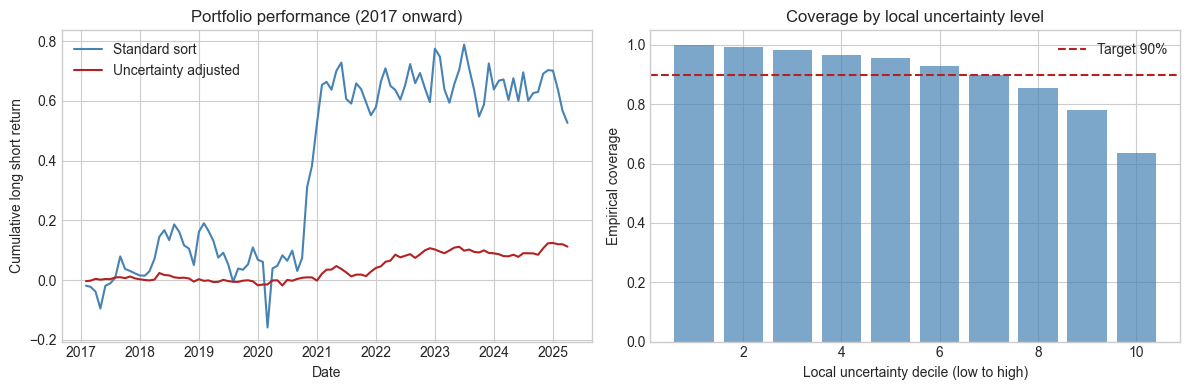

In [4]:
import os
os.makedirs("images", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: cumulative long short returns
ax = axes[0]
dates_plot = [dt for dt, _ in zip(test_dates, ls_std_list)]
ax.plot(dates_plot, np.cumsum(ls_std_arr), color='steelblue', lw=1.5, label='Standard sort')
ax.plot(dates_plot, np.cumsum(ls_ua_arr),  color='firebrick', lw=1.5, label='Uncertainty adjusted')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative long short return')
ax.set_title('Portfolio performance (2017 onward)')
ax.legend()

# Right: empirical coverage by local uncertainty decile
nn_sub    = NearestNeighbors(n_neighbors=50).fit(Xca_s)
_, idx_ca = nn_sub.kneighbors(Xca_s)
sigma_ca  = np.array([scores[idx].std() for idx in idx_ca])

decile    = pd.qcut(sigma_ca, 10, labels=False)
pred_ca   = mdl.predict(Xca_s)
cov_dec   = []
for d in range(10):
    m   = decile == d
    cov_dec.append(np.mean((yca[m] >= pred_ca[m] - q_hat) & (yca[m] <= pred_ca[m] + q_hat)))

ax2 = axes[1]
ax2.bar(range(1, 11), cov_dec, color='steelblue', alpha=0.7)
ax2.axhline(1 - alpha, color='firebrick', linestyle='--', label=f'Target {1 - alpha:.0%}')
ax2.set_xlabel('Local uncertainty decile (low to high)')
ax2.set_ylabel('Empirical coverage')
ax2.set_title('Coverage by local uncertainty level')
ax2.legend()

plt.tight_layout()
plt.savefig('images/conformal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

The left panel plots the cumulative returns of the two strategies over the test period. The right panel shows that empirical coverage is broadly uniform across local uncertainty deciles. This confirms the finite sample guarantee: regardless of how uncertain a prediction is, the conformal interval captures the true return at the specified rate.

(sec_ua_sorting)=
## Uncertainty adjusted portfolio sorting

The standard approach in empirical asset pricing is to sort stocks on point predictions and form decile portfolios. The top decile goes long and the bottom decile goes short. This ignores the reliability of each prediction. A stock at the top of the predicted return distribution may have a very wide confidence interval. Its prediction could easily be wrong.

@liu2026uncertainty propose uncertainty adjusted sorting. Instead of ranking stocks on their point prediction $\hat{f}(x)$, investors go long on stocks with the highest upper prediction bounds and short on stocks with the lowest lower prediction bounds. This selects confident predictions. A stock enters the long leg only if its lower bound is also elevated. A stock enters the short leg only if its upper bound is also low.

The key empirical finding from @liu2026uncertainty is that performance gains relative to standard sorting come mainly from reduced portfolio volatility rather than from higher average returns. The mechanism is asset level uncertainty rather than aggregate market uncertainty. When individual stock uncertainty is high, the sorting procedure naturally avoids those stocks, reducing idiosyncratic risk in the portfolio.

@allena2025confident reaches similar conclusions from a different angle. He derives ex ante confidence intervals from linear and ML models including Lasso, Elastic Net, Ridge and neural networks. Confident high low strategies, which trade only on stocks with precise forecasts, systematically outperform their standard counterparts. The result holds across all model classes. This convergence of evidence across methods suggests that incorporating forecast precision into portfolio construction is a robust improvement over point prediction sorting.

(sec_mfd)=
## Machine forecast disagreement

@bali2025disagreement introduce the concept of machine forecast disagreement (MFD). The idea draws on the classical analyst disagreement literature but replaces human analysts with ML model specifications. Different model architectures, different hyperparameters, and different feature sets produce different return forecasts for the same stock. The dispersion of these forecasts measures how much the "ML crowd" disagrees about a stock's prospects.

The analogy with investor disagreement is natural. In models with short sale constraints, disagreement among investors leads to overpricing because the most optimistic investors set prices while pessimists cannot easily arbitrage. The same logic applies here. Stocks with high MFD are harder to price, harder to arbitrage, and consequently overpriced.

Empirically, @bali2025disagreement find that stocks in the highest MFD decile earn returns roughly 14% per year lower than stocks in the lowest MFD decile on a value weighted basis. This spread is robust to standard risk controls. MFD also outperforms traditional analyst forecast dispersion measures in predicting cross sectional returns. The reason is that ML models cover the full cross section of stocks including those with no analyst coverage, and they do so at high frequency with consistent methodology.

The connection to limits to arbitrage is important. High MFD stocks tend to be small, illiquid, and costly to short. The same frictions that prevent arbitrageurs from correcting overpricing are correlated with the conditions that generate high ML disagreement. MFD therefore acts as a joint measure of uncertainty and arbitrage difficulty.

(sec_ambiguity)=
## Ambiguity aversion and portfolio choice

Knight distinguished risk, where probabilities are known, from ambiguity, where they are not. ML models introduce a specific form of ambiguity: different plausible models of the return generating process produce different optimal portfolios. @ghysels2022ambiguity quantify this ML ambiguity via bootstrap resampling. Each bootstrap resample yields a different trained model and hence a different forecast. The spread across resamples separately captures upside and downside scenarios, a concept the authors term directional uncertainty. Investors who internalize this ambiguity by adopting pessimistic positions where disagreement is high achieve better Sharpe ratios than those who rely on a single model estimate.

@hara2022ambiguity provide a theoretical foundation for thinking about implied ambiguity. They derive a one to one mapping between the degree of implied ambiguity inferred from portfolio inefficiency, the observed Sharpe ratio, and pricing errors in the cross section. The result holds under a smooth ambiguity model where the representative investor has preferences over both risk and ambiguity. Calibrating the model to US data, they find significant ambiguity aversion. This suggests that the equity premium itself reflects compensation not only for risk but for Knightian uncertainty about model parameters.

@bianchi2026uncertainty take a Bayesian neural network (BNN) approach to the same problem. Rather than mapping characteristics to expected returns, BNNs map firm characteristics directly to portfolio weights by maximizing expected utility under the posterior distribution over network parameters. The posterior induces a distribution over optimal weights. Averaging over this distribution yields more stable allocations than point estimates from standard deep learning. No trade regions arise naturally because the posterior uncertainty about a stock's weight may be so large that no position is justified. Posterior sparsity further reduces turnover. The resulting strategy outperforms linear models and standard neural networks, particularly after transaction costs, suggesting that parameter uncertainty is economically significant.

(sec_timevarying_unc)=
## Time varying uncertainty and signal selection

The optimal weighting of predictive signals changes over time. During periods of high economic uncertainty, short term signals become noisier while long term structural relationships remain more stable. @chen2026uncertainty formalize this intuition with U-LASSO, an adaptive penalization scheme that mixes long term and short term predictive signals based on the current level of economic uncertainty.

The mechanism operates through two distinct channels. The noisy signal channel, driven by real and financial uncertainty, pushes investors toward stable long term signals. These signals are less affected by transient shocks and provide more reliable forecasts when the environment is volatile. The volatile state channel, driven by macro uncertainty and the VIX, pushes investors toward short term signals because the economy is changing rapidly enough that long term averages become stale.

@chen2026uncertainty show that economic uncertainty explains nearly 30% of the variation in the optimal signal horizon weight. This is a large share of explained variation for a single variable and underlines the economic importance of the uncertainty regime. U-LASSO outperforms both traditional penalized regressions and standard ML benchmarks in out of sample portfolio performance. The result holds across different uncertainty measures and subperiods, suggesting robustness beyond any particular calibration choice.

(sec_llm_unc)=
## Uncertainty in large language model predictions

Large language models (LLMs) are increasingly used to classify financial text and generate investment signals. However, standard LLM outputs come with no natural measure of confidence. The model simply returns a predicted label or score. @chen2026llm address this gap by constructing an entropy measure from the inner conditional probabilities over possible outputs rather than from the generated text itself.

The approach exploits the token level probability distributions that LLMs compute internally. High entropy means the model is uncertain about which output to generate. Low entropy means the model assigns high probability to one particular output. Crucially, this inner probability differs from the confidence that some models report in their generated text. Decoding biases cause models to express false certainty in their generated language even when their internal distributions are diffuse. The entropy measure bypasses this problem.

@chen2026llm show that high confidence predictions (low entropy) are systematically more accurate in financial text classification tasks. A portfolio built on high confidence LLM signals achieves a Sharpe ratio approximately 20% above the benchmark. Low confidence predictions contribute no excess return. This finding implies that filtering LLM signals by their internal uncertainty is a meaningful source of alpha, and that practitioners should not rely on LLM self assessment to determine when to trust the model.

## Exercises

1. Using the simulated data above, vary the miscoverage level alpha from 0.05 to 0.30. Plot the empirical coverage and interval width as a function of alpha. Does the finite sample guarantee hold throughout?

2. Replace the ridge regression with a gradient boosting model. Recompute the conformal quantile and assess whether empirical coverage is maintained.

3. Implement an asymmetric conformal interval where the long leg uses the upper bound $\hat{f}(x) + \hat{q}$ and the short leg uses the lower bound $\hat{f}(x) - \hat{q}$. Compare the resulting portfolio with the uncertainty adjusted sort described in the chapter.

4. Simulate machine forecast disagreement by fitting five ridge regressions on different bootstrap samples of the training data. Compute the dispersion of predictions and test whether high disagreement stocks earn lower simulated returns.

5. Discuss conceptually how the U-LASSO of @chen2026uncertainty could be implemented in a panel regression setting. What observable variable would you use as the uncertainty measure, and how would it enter the penalization scheme?